In [271]:
from typing import TypedDict, Optional, List
from langgraph.graph import StateGraph, END
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.vectorstores import FAISS
from langchain_tavily import TavilySearch
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

from langchain_neo4j import Neo4jGraph
import os
from dotenv import  load_dotenv
load_dotenv()
NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
neo4j = Neo4jGraph(url=NEO4J_URI,username=NEO4J_USERNAME,password=NEO4J_PASSWORD,refresh_schema=False)
neo4j


In [272]:

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [273]:
from langchain.chat_models import init_chat_model

from backend.config import GROQ_API_KEY
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
""" model = init_chat_model("google_genai:gemini-2.5-flash")
 """
from langchain_groq import ChatGroq

model = ChatGroq(
    model="moonshotai/kimi-k2-instruct-0905",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

#model = init_chat_model("google_genai:gemini-1.5-flash")

In [274]:

import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from langchain_ollama import ChatOllama



embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

movie_db = FAISS.load_local(
    "artifacts/movie_faiss_v3",
    embeddings,
    allow_dangerous_deserialization=True
)

# Load cleaned dataset for movie existence checks
df1_cleaned = pd.read_csv('df1_cleaned.csv')


In [275]:
neo4j = Neo4jGraph(url=NEO4J_URI,username=NEO4J_USERNAME,password=NEO4J_PASSWORD,refresh_schema=False)
neo4j

In [276]:
def run_cypher(query, params=None):
    print(f"\n--- Executing Cypher ---")
    print(f"Query:\n{query}")
    print(f"Params:\n{params}")
    try:
        # neo4j is a Neo4jGraph instance, use query() method
        results = neo4j.query(query, params or {})
        print(f"Cypher Result Count: {len(results)}")
        return results
    except Exception as e:
        print(f"Cypher Execution Error: {e}")
        return []

In [277]:
class IntentClassification(BaseModel):
    """The intent category of the user's movie query."""
    intent: str = Field(
        description="Must be one of: 'plot' (describing a story), 'movie_name' (specific movie title), 'query_search' (complex query), or 'invalid' (gibberish, off-topic, or random text)."
    )
    confidence_score: float = Field(description="Confidence from 0.0 to 1.0")

In [278]:
class MovieState(TypedDict):
    query: str
    intent: Optional[str]
    movie_name: Optional[str]
    movie_exists: Optional[bool]
    base_plot: Optional[str]
    kg_movies: Optional[List[str]]
    kg_sparse: Optional[bool]
    web_context: Optional[str]
    needs_clarification: Optional[bool]    # ← NEW
    clarification_question: Optional[str]  # ← NEW
    final_docs: Optional[List[Document]]
    final_answer: Optional[str]

In [279]:
structured_llm_classify = model.with_structured_output(IntentClassification)

In [280]:
import json
import re

# ── Classifier ──────────────────────────────────────────────
def classify_query(state: MovieState):
    print(f"\n--- Node: Classify Query ---")

    prompt = f"""You are a Movie Intent Classifier. Analyze the query and return ONLY a JSON object.

INTENTS:
- "plot"         : user describes a story/scene (e.g. "movie where a man grows potatoes on Mars")
- "movie_name"   : user names a specific movie and wants similar ones (e.g. "movies like Inception")
- "query_search" : user filters by actor / director / genre / year (e.g. "Tom Hanks action movies")
- "invalid"      : gibberish or completely off-topic

Return ONLY this JSON, nothing else:
{{"intent": "plot|movie_name|query_search|invalid", "confidence_score": 0.0}}

Query: "{state['query']}"
"""

    raw = model.invoke(prompt).content.strip()

    # Strip accidental markdown
    raw = re.sub(r"```json|```", "", raw).strip()

    try:
        parsed = json.loads(raw)
        intent = parsed.get("intent", "invalid")
        score  = parsed.get("confidence_score", 0.0)
    except json.JSONDecodeError:
        # Fallback: scan raw text for intent keyword
        intent = "invalid"
        for candidate in ["plot", "movie_name", "query_search"]:
            if candidate in raw.lower():
                intent = candidate
                break
        score = 0.5

    print(f"Identified Intent: {intent} (Confidence: {score})")
    return {"intent": intent}


# ── Updated extract_kg_entities ────────────────────────────────
def extract_kg_entities(query: str) -> dict:
    prompt = f"""Extract movie search filters from the query. Return ONLY a JSON object.

Keys (use null if not mentioned):
- actor    : most distinctive part of actor name only (e.g. "amitabh" not "Amitabh Bachchan")
- director : most distinctive part of director name only (e.g. "nolan" not "Christopher Nolan")
- genre    : single most relevant genre keyword (e.g. "thriller", "horror", "comedy")
- year_min : minimum year as integer or null
- year_max : maximum year as integer or null  
- keywords : list of plot keywords or null

CRITICAL RULES:
- For actor/director: use ONLY the most unique part of the name (first OR last name, not both)
  "Amitabh Bachchan" → "amitabh"
  "Tom Hanks"        → "hanks"  
  "Shah Rukh Khan"   → "shah rukh"
  "Christopher Nolan"→ "nolan"
- For genre: use a single lowercase keyword that will appear inside compound genres
  "thriller" will match "Action-Thriller", "Crime/Thriller", "Psychological Thriller" etc.
  "horror"   will match "Horror/Thriller", "Horror Drama" etc.
- For decades: "90s" → year_min:1990, year_max:1999 | "2000s" → year_min:2000, year_max:2009
- For "recent/latest/new" → year_min:2015, year_max:null

Examples:
"Amitabh Bachchan thriller"
→ {{"actor":"amitabh","director":null,"genre":"thriller","year_min":null,"year_max":null,"keywords":null}}

"Shah Rukh Khan romantic movies from 2000s"
→ {{"actor":"shah rukh","director":null,"genre":"romance","year_min":2000,"year_max":2009,"keywords":null}}

"Nolan psychological films"
→ {{"actor":null,"director":"nolan","genre":"psychological","year_min":null,"year_max":null,"keywords":null}}

Query: "{query}"
"""
    raw = model.invoke(prompt).content.strip()
    raw = re.sub(r"```json|```", "", raw).strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        print(f"Entity extraction parse failed, raw: {raw}")
        return {"actor": None, "director": None, "genre": None,
                "year_min": None, "year_max": None, "keywords": None}

In [281]:
def handle_invalid(state: MovieState):
    print("--- Node: Handle Invalid/Gibberish ---")
    
    # You can also use an LLM here to generate a more creative response
    # For now, we'll use a static, clear message to save tokens.
    message = (
        "I'm sorry, I didn't quite understand that. "
        "Could you please describe a movie plot, provide a title, "
        "or ask a specific question about actors or genres?"
    )
    
    return {"final_answer": message}

In [282]:
# ── Fix 1: extract_movie_name — extract regardless of knowledge ─

def extract_movie_name(state: MovieState):
    print(f"\n--- Node: Extract Movie Name ---")

    prompt = f"""Extract the movie title from the user's query.

Rules:
- Extract whatever title the user mentions, even if you don't recognize it
- The movie may be regional, recent, or obscure — extract it anyway
- If truly no movie title is present, respond with NONE
- Return ONLY the movie title, nothing else

Examples:
"movies like Dhurandhar"          → Dhurandhar
"something similar to RRR"        → RRR  
"recommend films like KGF"        → KGF
"movies like Metro In Dino"       → Metro In Dino
"I want a thriller"               → NONE

Query: {state['query']}
"""

    response = model.invoke(prompt)
    name = response.content.strip() if isinstance(response.content, str) else str(response.content).strip()
    name = re.sub(r"```.*?```", "", name, flags=re.DOTALL).strip()

    print(f"Extracted Name: {name}")

    if "NONE" in name.upper() or not name:
        return {"movie_name": None}

    return {"movie_name": name}

In [283]:

def check_movie_exists(state: MovieState):
    print(f"--- Node: Check Movie Exists ---")
    title = state["movie_name"]
    # Use df1_cleaned for existence check
    exists = df1_cleaned['Title'].str.lower().str.contains(title.lower(), na=False).any()
    print(f"Movie Exists in DB: {exists}")
    return {"movie_exists": exists}


In [284]:

def get_dataset_plot(state: MovieState):
    print(f"--- Node: Get Dataset Plot ---")
    title = state["movie_name"]
    # Use df1_cleaned for plot retrieval
    mask = df1_cleaned['Title'].str.lower().str.contains(title.lower(), na=False)
    if mask.any():
        plot = df1_cleaned.loc[mask, 'Plot'].iloc[0]
        print("Retrieved plot from Dataset.")
        return {"base_plot": plot}
    print("Movie not found in Dataset.")
    return {"base_plot": None}


In [285]:
from langchain_tavily import TavilySearch
tool = TavilySearch(
    max_results=1,
    topic="general",
    include_raw_content=True,
    include_answer=True,
    search_depth="advanced",
    time_range=None,
    include_images=True,
)

In [286]:
import json
import re

In [287]:
import re

def get_web_plot(state: MovieState):
    print("--- Node: Get Web Plot ---")

    movie_name = state.get("movie_name", "")

    # 🔒 Normalize movie_name (CRITICAL)
    if isinstance(movie_name, dict):
        movie_name = movie_name.get("text", "")
    elif not isinstance(movie_name, str):
        movie_name = str(movie_name)

    movie_name = movie_name.strip()

    if not movie_name:
        return {"base_plot": "No movie name provided."}

    try:
        # 1. Build search query
        search_query = f"movie {movie_name} plot summary wikipedia"
        print(f"Searching Tavily with query: {search_query}")

        # 2. Call Tavily
        raw_response = tool.invoke({"query": search_query})

        # ✅ SAFE inspection (NO json.dumps)
        print("Tavily response type:", type(raw_response))
        if isinstance(raw_response, dict):
            print("Tavily response keys:", raw_response.keys())

        # 3. Extract content safely
        results = raw_response.get("results", []) if isinstance(raw_response, dict) else []

        target_content = ""
        source_url = ""

        for r in results:
            if isinstance(r, dict) and r.get("content"):
                target_content = r["content"]
                source_url = r.get("url", "Unknown Source")
                break

        if not target_content:
            print(f"No plot found for {movie_name}")
            return {"base_plot": "No plot found on the web."}

        print(f"Plot source: {source_url}")

        # 4. Clean text
        def clean_text(text) -> str:
            # Handle list input just in case
            if isinstance(text, list):
                text = " ".join(map(str, text))
            if not isinstance(text, str):
                text = str(text)

            text = text.replace("\\n", " ").replace("\n", " ").replace("\t", " ")
            text = re.sub(r"\[\d+\]", "", text)     # remove citations [1]
            text = re.sub(r"\[|\]", "", text)       # remove stray brackets
            text = re.sub(r"\s+", " ", text)
            return text.strip()

        plot = clean_text(target_content)

        if not plot:
            return {"base_plot": "Plot extraction failed after cleaning."}

        print(f"Successfully retrieved plot for {movie_name}")
        print(f"Extracted Plot for Verbose:\n{plot}")
        return {"base_plot": plot}

    except Exception as e:
        print(f"Web Search Error at extraction: {e}")
        return {"base_plot": f"Error during web search: {str(e)}"}


In [288]:

class MovieFilters(BaseModel):
    """Extracted entities for advanced Knowledge Graph querying."""
    actor: Optional[str] = Field(None, description="Name of the actor.")
    director: Optional[str] = Field(None, description="Name of the director.")
    genre: Optional[str] = Field(None, description="The movie genre.")
    keywords: Optional[List[str]] = Field(
        default_factory=list, 
        description="Key plot points or themes (e.g., 'time travel', 'sinking ship')."
    )

In [289]:
structured_extractor = model.with_structured_output(MovieFilters)

In [290]:
# ── Cypher-writing agent ──────────────────────────────────────

KG_SCHEMA = """
You are an expert Neo4j Cypher query writer for a movie knowledge graph.

SCHEMA:
  Nodes:
    - (m:Movie)     properties: title (string), year (integer), plot (string)
    - (a:Actor)     properties: name (string)
    - (d:Director)  properties: name (string)
    - (g:Genre)     properties: name (string)

  Relationships (all go OUTWARD from Movie):
    - (m:Movie)-[:FEATURES]->(a:Actor)
    - (m:Movie)-[:DIRECTED_BY]->(d:Director)
    - (m:Movie)-[:BELONGS_TO]->(g:Genre)

RULES:
  1. Only use the nodes, relationships and properties listed above. Nothing else exists.
  2. Always use DISTINCT to avoid duplicate movies.
  3. Always end with: RETURN DISTINCT m.title AS title, m.year AS year ORDER BY m.year DESC LIMIT 15
  4. Use toLower() on both sides for all string comparisons.
  5. For decade queries like "90s" use: m.year >= 1990 AND m.year <= 1999
  6. For "recent" or "latest" use: m.year >= 2015
  7. Only MATCH a relationship if you actually need to filter on it.
  8. Use CONTAINS for partial name matches, not = (equals).
  9. Return ONLY the raw Cypher query. No explanation, no markdown, no backticks.
"""


def cypher_agent(state: MovieState):
    print(f"\n--- Node: Cypher Agent ---")

    entities = extract_kg_entities(state['query'])
    print(f"Entities: {entities}")

    KG_SCHEMA = f"""
You are a Neo4j Cypher expert for a movie knowledge graph.

SCHEMA:
  (m:Movie)     props: title (string), year (integer), plot (string)
  (a:Actor)     props: name (string)
  (d:Director)  props: name (string)
  (g:Genre)     props: name (string)  ← compound strings like "Action-Thriller", "Crime / Thriller"
                                         ALWAYS use CONTAINS, never =
  Relationships (outward from Movie):
  (m)-[:FEATURES]->(a:Actor)
  (m)-[:DIRECTED_BY]->(d:Director)
  (m)-[:BELONGS_TO]->(g:Genre)

EXTRACTED ENTITIES:
  actor    = {entities.get('actor')}
  director = {entities.get('director')}
  genre    = {entities.get('genre')}
  year_min = {entities.get('year_min')}
  year_max = {entities.get('year_max')}
  keywords = {entities.get('keywords')}

RULES:
  1. Only MATCH a relationship if its entity is not null above.
  2. ALWAYS use toLower() + CONTAINS for ALL string comparisons. Never use =.
  3. Apply year_min/year_max on m.year if not null.
  4. Always end with: RETURN DISTINCT m.title AS title, m.year AS year ORDER BY m.year DESC LIMIT 15
  5. Return ONLY raw Cypher. No markdown, no backticks, no explanation.

EXAMPLE for actor="amitabh", genre="thriller":
  MATCH (m:Movie)-[:FEATURES]->(a:Actor)
  MATCH (m)-[:BELONGS_TO]->(g:Genre)
  WHERE toLower(a.name) CONTAINS 'amitabh'
  AND toLower(g.name) CONTAINS 'thriller'
  RETURN DISTINCT m.title AS title, m.year AS year
  ORDER BY m.year DESC LIMIT 15

Write the Cypher now:
"""

    MAX_RETRIES = 3
    last_error  = None

    for attempt in range(MAX_RETRIES):
        raw    = model.invoke(KG_SCHEMA).content.strip()
        cypher = re.sub(r"```cypher|```", "", raw).strip()
        print(f"Attempt {attempt+1} Cypher:\n{cypher}\n")

        try:
            results = neo4j.query(cypher)
            titles  = [r["title"] for r in results]
            print(f"KG Found {len(titles)} titles: {titles}")

            # ── Sparse check ──────────────────────────────────
            SPARSE_THRESHOLD = 3
            is_sparse = len(titles) < SPARSE_THRESHOLD
            if is_sparse:
                print(f"⚠️  Sparse result ({len(titles)} < {SPARSE_THRESHOLD}) — will fallback to web")

            return {
                "kg_movies": titles,
                "kg_sparse": is_sparse
            }

        except Exception as e:
            last_error  = str(e)
            print(f"Error: {last_error}")
            KG_SCHEMA  += f"""
Your previous attempt failed:
Error: {last_error}
Broken Cypher: {cypher}
Fix it and write only the corrected Cypher:"""

    # All retries failed — treat as sparse
    return {"kg_movies": [], "kg_sparse": True}

In [291]:
def kg_web_fallback(state: MovieState):
    print("\n--- Node: KG Web Fallback ---")

    # ── Build a precise search query from entities ─────────────
    entities = extract_kg_entities(state['query'])
    
    parts = []
    if entities.get('actor'):
        # Use full corrected name for web search, not the shortened KG version
        parts.append(entities['actor'])
    if entities.get('director'):
        parts.append(f"directed by {entities['director']}")
    if entities.get('genre'):
        parts.append(entities['genre'])
    if entities.get('year_min') and entities.get('year_max'):
        parts.append(f"from {entities['year_min']} to {entities['year_max']}")
    elif entities.get('year_min'):
        parts.append(f"after {entities['year_min']}")
    if entities.get('keywords'):
        parts.append(" ".join(entities['keywords']))

    structured_query = " ".join(parts) + " best movies list"
    
    print(f"Structured search query: {structured_query}")

    # ── Run multiple targeted searches ─────────────────────────
    search_queries = [
        structured_query,
        f"{structured_query} site:imdb.com",
    ]

    web_context = ""
    for q in search_queries:
        try:
            raw      = tool.invoke({"query": q})
            results  = raw.get("results", [])
            for r in results[:2]:
                if r.get("content"):
                    web_context += f"Source: {r.get('url', '')}\n"
                    web_context += r["content"][:800] + "\n\n"
            if len(web_context) > 1500:
                break
        except Exception as e:
            print(f"Search error for '{q}': {e}")
            continue

    if not web_context:
        print("No web results found")
        return {"web_context": None}

    print(f"Web context retrieved ({len(web_context)} chars)")
    return {
        "web_context": web_context,
        "base_plot": web_context   # keep base_plot in sync for similarity_search fallback
    }

In [292]:
def generate_from_web(state: MovieState):
    print("\n--- Node: Generate From Web ---")

    web_context = state.get("web_context")
    entities    = extract_kg_entities(state['query'])

    if not web_context:
        return {
            "final_answer": (
                f"I couldn't find enough results for '{state['query']}' "
                "in my database or on the web. Try rephrasing or being more specific."
            )
        }

    # Build constraint string for the LLM prompt
    constraints = []
    if entities.get('actor'):
        constraints.append(f"starring {entities['actor']}")
    if entities.get('director'):
        constraints.append(f"directed by {entities['director']}")
    if entities.get('genre'):
        constraints.append(f"in the {entities['genre']} genre")
    if entities.get('year_min') and entities.get('year_max'):
        constraints.append(f"released between {entities['year_min']} and {entities['year_max']}")
    elif entities.get('year_min'):
        constraints.append(f"released after {entities['year_min']}")
    constraint_str = ", ".join(constraints) if constraints else "matching the user's request"

    prompt = f"""You are a helpful movie recommendation assistant.

The user asked: "{state['query']}"

I searched the web and found this information:
{web_context}

Your job:
- Recommend movies {constraint_str}
- Only mention movies explicitly found in the web content above
- If the web content mentions movies that do NOT match the constraints (wrong year, wrong actor), skip them
- If you genuinely cannot find enough matching movies, say so honestly and suggest the user try a more specific search
- List each movie with title, year, and one sentence on why it fits
- Keep it conversational
"""

    answer = model.invoke(prompt).content
    print(f"Web-based answer generated (len: {len(answer)})")
    return {"final_answer": answer}

In [293]:
# ── Fixed kg_results_to_docs ───────────────────────────────────
def kg_results_to_docs(state: MovieState):
    print("--- Node: KG Results to Docs ---")

    titles = state.get("kg_movies", [])
    docs   = []

    for title in titles:
        # 1. Try exact match in df1_cleaned first
        mask = df1_cleaned['Title'].str.lower() == title.lower()

        if not mask.any():
            # 2. Fallback: contains match
            mask = df1_cleaned['Title'].str.lower().str.contains(
                title.lower(), na=False, regex=False
            )

        if mask.any():
            row  = df1_cleaned[mask].iloc[0]
            plot = row.get('Plot') or row.get('clean_plot') or ""
            doc  = Document(
                page_content=str(plot),
                metadata={"title": row['Title']}
            )
            docs.append(doc)
        else:
            # 3. Last resort: FAISS (only if title not in CSV)
            faiss_matches = movie_db.similarity_search(title, k=1)
            if faiss_matches:
                docs.append(faiss_matches[0])

    print(f"Fetched {len(docs)} docs for {len(titles)} KG titles")
    return {"final_docs": docs}

In [294]:
from sentence_transformers import CrossEncoder

# Load this ONCE at the top of your notebook, not inside the function
reranker_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2') 

def hybrid_rerank(state: MovieState):
    print("\n--- Node: Hybrid Rerank (Cross-Encoder) ---")
    docs = state.get("final_docs", [])
    if not docs: return {"final_docs": []}

    query = state["query"]
    
    # Prepare pairs for the Cross-Encoder [ [Query, Doc_Text], ... ]
    pairs = [[query, d.page_content] for d in docs]
    
    # Get scores (0 to 1)
    scores = reranker_model.predict(pairs)
    
    ranked_docs = []
    for i, doc in enumerate(docs):
        # 1. Semantic Score from Cross-Encoder
        semantic_score = scores[i]
        
        # 2. Symbolic Score (Boost if it came from Knowledge Graph)
        symbolic_score = 0.0
        if state.get("kg_movies") and doc.metadata.get("title") in state["kg_movies"]:
            symbolic_score = 0.3 # Boost KG matches
            
        final_score = semantic_score + symbolic_score
        
        # Store score in metadata for debugging
        doc.metadata["rerank_score"] = float(final_score)
        ranked_docs.append((final_score, doc))
        
    # Sort descending
    ranked_docs.sort(key=lambda x: x[0], reverse=True)
    
    # Return top 5
    top_docs = [doc for _, doc in ranked_docs[:5]]
    return {"final_docs": top_docs}

In [295]:


def similarity_search(state: MovieState):
    print(f"\n--- Node: Similarity Search (aggregated) ---")
    query_text = state.get("base_plot") or state["query"]
    
    # 1. Fetch MORE chunks than you need (e.g., k=20 or 50)
    # This ensures we get chunks from different movies, not just the top 1 movie
    raw_docs = movie_db.similarity_search(query_text, k=25)
    
    # 2. Group chunks by Movie Name (Deduplicate)
    unique_movies = {}
    for doc in raw_docs:
        title = doc.metadata.get("title", "Unknown")
        
        # If we haven't seen this movie yet, add it
        if title not in unique_movies:
            unique_movies[title] = {
                "doc": doc,
                "score": 0.0, # You can implement score tracking if using search_with_score
                "chunks": [doc.page_content]
            }
        else:
            # Optionally append more context from other chunks
            unique_movies[title]["chunks"].append(doc.page_content)
    
    # 3. Limit to top 5 UNIQUE movies
    final_docs = []
    for title, data in list(unique_movies.items())[:5]:
        # Optional: Combine text from multiple chunks to give LLM better context
        # combined_text = " ... ".join(data["chunks"]) 
        # data["doc"].page_content = combined_text 
        final_docs.append(data["doc"])
        
    print(f"Aggregated to {len(final_docs)} unique movies.")
    return {"final_docs": final_docs}

In [296]:
def generate_answer(state: MovieState):
    print(f"\n--- Node: Generate Answer ---")

    docs       = state.get("final_docs", [])
    kg_movies  = state.get("kg_movies", [])

    if not docs:
        return {
            "final_answer": (
                "I couldn't find enough matching movies. "
                "Could you provide more details?"
            )
        }

    # Build context — title + plot snippet
    context = "\n\n".join(
        f"{d.metadata.get('title', 'Unknown')} ({d.metadata.get('year', '')}): "
        f"{d.page_content[:400]}"
        for d in docs
    )

    # Tell LLM exactly which titles the KG confirmed are relevant
    kg_titles_str = "\n".join(f"- {t}" for t in kg_movies) if kg_movies else "N/A"

    prompt = f"""You are a helpful movie recommendation assistant.

User query: "{state['query']}"

The knowledge graph confirmed these movies match the query exactly:
{kg_titles_str}

Here are their plot summaries:
{context}

Instructions:
- Recommend ONLY the movies listed above — these are verified matches
- For each movie give the title, year, and a brief reason why it fits the query
- If plots don't match the query well, still trust the KG titles and explain what you know
- Be conversational and helpful
"""

    answer = model.invoke(prompt).content
    print(f"Final answer generated (len: {len(answer)})")
    return {"final_answer": answer}

In [297]:
def clarification_node(state: MovieState):
    """
    Triggered when: movie name extracted but not in DB and web found nothing.
    Asks user to confirm spelling or provide more context.
    """
    print("\n--- Node: Clarification ---")

    movie_name = state.get("movie_name", "")
    base_plot  = state.get("base_plot", "")

    # If web search returned something, no clarification needed
    if base_plot and len(base_plot) > 100:
        return {"needs_clarification": False}

    # Build a smart clarification question using LLM
    prompt = f"""The user asked for movies similar to "{movie_name}", 
but I couldn't find this movie in my database or on the web.

Generate a short, friendly clarification message that:
1. Acknowledges the movie wasn't found
2. Asks if the spelling is correct OR if they can describe the movie's plot
3. Suggests they might mean a similar well-known title if applicable
4. Keeps it under 3 sentences

Return ONLY the clarification message, nothing else.
"""
    question = model.invoke(prompt).content.strip()
    print(f"Clarification question: {question}")

    return {
        "needs_clarification": True,
        "clarification_question": question,
        "final_answer": question   # surfaces to user immediately
    }

In [298]:

# --- Routing Logic ---
def route_after_classification(state):
    intent = state.get("intent")
    if intent == "plot":
        return "similarity_search"  # Flow 1: Semantic Search
    elif intent == "movie_name":
        return "extract_movie_name" # Flows 2 & 3: Specific Name
    elif intent == "query_search":
        return "kg_agent"         # Flow 4: Query/KG Search
    elif intent == "invalid":
        return "handle_invalid"
    return "kg_agent"

def route_after_extraction(state):
    if state.get("movie_name"):
        return "check_movie_exists"
    else:
        # Fallback if classified as movie_name but no name found
        # Could go to plot search or end. Sending to plot search seems safest.
        return "similarity_search"

def route_movie_exists(state):
    if state["movie_exists"]:
        return "get_dataset_plot"  # Flow 2: Existing in Dataset
    return "get_web_plot"          # Flow 3: Web Search

# ── Updated routing ────────────────────────────────────────────

# After cypher_agent — route based on sparse flag
def route_after_kg(state: MovieState):
    if state.get("kg_sparse"):
        return "kg_web_fallback"
    return "kg_results_to_docs"

def route_after_kg_web_fallback(state: MovieState):
    # If web got content → generate directly, skip FAISS entirely
    if state.get("web_context"):
        return "generate_from_web"
    # Web also failed → fall back to generic FAISS similarity search
    return "similarity_search"

def route_after_web_plot(state: MovieState):
    """Route based on whether web search found useful content."""
    base_plot = state.get("base_plot", "")

    if base_plot and len(base_plot) > 100:
        return "similarity_search"      # web found content → proceed normally
    return "clarification_node"         # web found nothing → ask user
# ── 5. Updated graph ───────────────────────────────────────────

# ── Updated graph with clarification node ──────────────────────

graph = StateGraph(MovieState)

graph.add_node("classify_query",     classify_query)
graph.add_node("extract_movie_name", extract_movie_name)
graph.add_node("check_movie_exists", check_movie_exists)
graph.add_node("get_dataset_plot",   get_dataset_plot)
graph.add_node("get_web_plot",       get_web_plot)
graph.add_node("clarification_node", clarification_node)   # ← NEW
graph.add_node("kg_agent",           cypher_agent)
graph.add_node("kg_results_to_docs", kg_results_to_docs)
graph.add_node("kg_web_fallback",    kg_web_fallback)
graph.add_node("generate_from_web",  generate_from_web)
graph.add_node("hybrid_rerank",      hybrid_rerank)
graph.add_node("similarity_search",  similarity_search)
graph.add_node("generate_answer",    generate_answer)
graph.add_node("handle_invalid",     handle_invalid)

graph.set_entry_point("classify_query")

graph.add_conditional_edges("classify_query", route_after_classification, {
    "similarity_search":  "similarity_search",
    "extract_movie_name": "extract_movie_name",
    "kg_agent":           "kg_agent",
    "handle_invalid":     "handle_invalid"
})
graph.add_conditional_edges("extract_movie_name", route_after_extraction, {
    "check_movie_exists": "check_movie_exists",
    "similarity_search":  "similarity_search"
})
graph.add_conditional_edges("check_movie_exists", route_movie_exists, {
    "get_dataset_plot": "get_dataset_plot",
    "get_web_plot":     "get_web_plot"
})

# ── NEW: after web plot, check if we got useful content ────────
graph.add_conditional_edges("get_web_plot", route_after_web_plot, {
    "similarity_search":  "similarity_search",
    "clarification_node": "clarification_node"   # ← unknown movie → ask user
})

graph.add_conditional_edges("kg_agent", route_after_kg, {
    "kg_web_fallback":    "kg_web_fallback",
    "kg_results_to_docs": "kg_results_to_docs"
})
graph.add_conditional_edges("kg_web_fallback", route_after_kg_web_fallback, {
    "generate_from_web": "generate_from_web",
    "similarity_search": "similarity_search"
})

graph.add_edge("get_dataset_plot",   "similarity_search")
graph.add_edge("similarity_search",  "hybrid_rerank")
graph.add_edge("kg_results_to_docs", "hybrid_rerank")
graph.add_edge("hybrid_rerank",      "generate_answer")
graph.add_edge("generate_answer",    END)
graph.add_edge("generate_from_web",  END)
graph.add_edge("clarification_node", END)   # ← surfaces question, waits for user
graph.add_edge("handle_invalid",     END)

app = graph.compile()

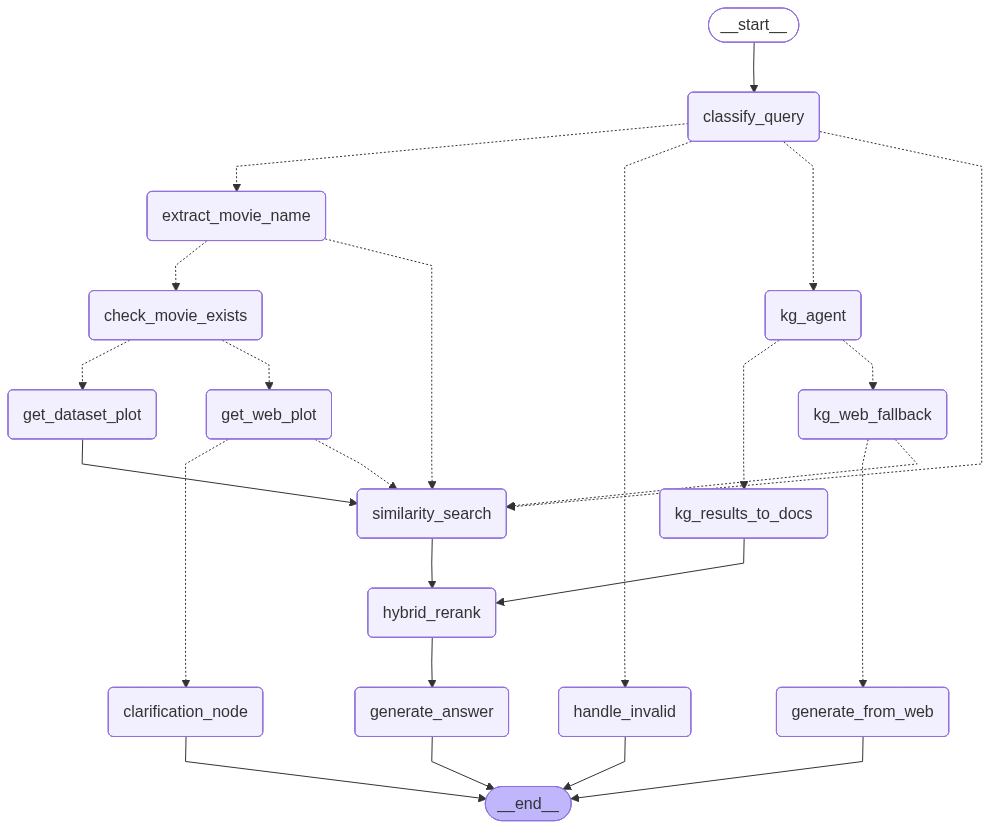

In [299]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [300]:
""" result = app.invoke({
    "query": " movie with amitabh bacchan and thriller "
})

print(result["final_answer"]) """


' result = app.invoke({\n    "query": " movie with amitabh bacchan and thriller "\n})\n\nprint(result["final_answer"]) '

In [301]:
""" tests = [
    "salman khan action movies from 90s",       # should now search "salman 1990 to 1999 action best movies list"
    "rajinikanth comedy films",                  # should now search "rajinikanth comedy best movies list"  
    "amitabh bachchan thriller",                 # already working, confirm still works
    "movies directed by mani ratnam",            # director-only query
    "aamir khan movies from 2000 to 2010",       # actor + year range
]

for q in tests:
    print(f"\n{'='*50}")
    result = app.invoke({"query": q})
    print(f"Q      : {q}")
    print(f"Sparse : {result.get('kg_sparse')}")
    print(f"Answer : {result.get('final_answer', '')[:400]}") """

' tests = [\n    "salman khan action movies from 90s",       # should now search "salman 1990 to 1999 action best movies list"\n    "rajinikanth comedy films",                  # should now search "rajinikanth comedy best movies list"  \n    "amitabh bachchan thriller",                 # already working, confirm still works\n    "movies directed by mani ratnam",            # director-only query\n    "aamir khan movies from 2000 to 2010",       # actor + year range\n]\n\nfor q in tests:\n    print(f"\n{\'=\'*50}")\n    result = app.invoke({"query": q})\n    print(f"Q      : {q}")\n    print(f"Sparse : {result.get(\'kg_sparse\')}")\n    print(f"Answer : {result.get(\'final_answer\', \'\')[:400]}") '

In [302]:
""" tests = [
    "movies directed by mani ratnam",
    "aamir khan movies from 2000 to 2010",
]

for q in tests:
    print(f"\n{'='*50}")
    result = app.invoke({"query": q})
    print(f"Q       : {q}")
    print(f"KG hits : {result.get('kg_movies', [])[:5]}")
    print(f"Docs    : {[d.metadata.get('title') for d in (result.get('final_docs') or [])][:5]}")
    print(f"Answer  : {result.get('final_answer', '')[:400]}") """

' tests = [\n    "movies directed by mani ratnam",\n    "aamir khan movies from 2000 to 2010",\n]\n\nfor q in tests:\n    print(f"\n{\'=\'*50}")\n    result = app.invoke({"query": q})\n    print(f"Q       : {q}")\n    print(f"KG hits : {result.get(\'kg_movies\', [])[:5]}")\n    print(f"Docs    : {[d.metadata.get(\'title\') for d in (result.get(\'final_docs\') or [])][:5]}")\n    print(f"Answer  : {result.get(\'final_answer\', \'\')[:400]}") '

In [305]:
result = app.invoke({
    "query": " movies like dhurandhar "
})

print(result["final_answer"])


--- Node: Classify Query ---
Identified Intent: movie_name (Confidence: 0.9)

--- Node: Extract Movie Name ---
Extracted Name: Dhurandhar
--- Node: Check Movie Exists ---
Movie Exists in DB: False
--- Node: Get Web Plot ---
Searching Tavily with query: movie Dhurandhar plot summary wikipedia
Tavily response type: <class 'dict'>
Tavily response keys: dict_keys(['query', 'response_time', 'follow_up_questions', 'answer', 'images', 'results', 'request_id'])
Plot source: https://en.wikipedia.org/wiki/Dhurandhar
Successfully retrieved plot for Dhurandhar
Extracted Plot for Verbose:
Dhurandhar is a 2025 Indian Hindi-language spy action thriller film written, co-produced, and directed by Aditya Dhar. It was produced by Jyoti Deshpande, Aditya Dhar, and Lokesh Dhar, under Jio Studios and B62 Studios. The film features an ensemble cast consisting of Ranveer Singh, Akshaye Khanna, Sanjay Dutt, Arjun Rampal, R. Madhavan, Sara Arjun, Rakesh Bedi, Gaurav Gera, and Danish Pandor "Danish Pandor (acto

In [304]:
edge_cases = [
    "movies like dhurandhar",           # post-cutoff Marathi film
    "movies similar to pushpa 2",       # recent Telugu
    "something like metro in dino",     # upcoming Hindi
    "films like kanguva",               # recent Tamil
    "movies like abcd1234xyz",          # genuinely doesn't exist
]

for q in edge_cases:
    print(f"\n{'='*50}")
    result = app.invoke({"query": q})
    print(f"Q              : {q}")
    print(f"Extracted name : {result.get('movie_name')}")
    print(f"Movie exists   : {result.get('movie_exists')}")
    print(f"Needs clarif.  : {result.get('needs_clarification')}")
    print(f"Answer         : {result.get('final_answer', '')[:300]}")



--- Node: Classify Query ---
Identified Intent: movie_name (Confidence: 0.8)

--- Node: Extract Movie Name ---
Extracted Name: Dhurandhar
--- Node: Check Movie Exists ---
Movie Exists in DB: False
--- Node: Get Web Plot ---
Searching Tavily with query: movie Dhurandhar plot summary wikipedia
Tavily response type: <class 'dict'>
Tavily response keys: dict_keys(['query', 'follow_up_questions', 'answer', 'images', 'results', 'response_time', 'request_id'])
Plot source: https://en.wikipedia.org/wiki/Dhurandhar
Successfully retrieved plot for Dhurandhar
Extracted Plot for Verbose:
Dhurandhar is a 2025 Indian Hindi-language spy action thriller film written, co-produced, and directed by Aditya Dhar. It was produced by Jyoti Deshpande, Aditya Dhar, and Lokesh Dhar, under Jio Studios and B62 Studios. The film features an ensemble cast consisting of Ranveer Singh, Akshaye Khanna, Sanjay Dutt, Arjun Rampal, R. Madhavan, Sara Arjun, Rakesh Bedi, Gaurav Gera, and Danish Pandor "Danish Pandor (act